正在运行 Grid Search 以获取基准曲线...
Grid Search 完成。
{'S': tensor([0.0100, 0.0500, 0.1000, 0.1500, 0.2000, 0.2500, 0.3000, 0.3500, 0.4000,
        0.4500, 0.5000, 0.5500, 0.6000, 0.6500, 0.7000, 0.7500, 0.8000, 0.8500,
        0.9000, 0.9500, 1.0000, 1.0500, 1.1000, 1.1500, 1.2000, 1.2500, 1.3000,
        1.3500, 1.4000, 1.4500, 1.5000, 1.5500, 1.6000, 1.6500, 1.7000, 1.7500,
        1.8000, 1.8500, 1.9000, 1.9500, 2.0000, 2.0500, 2.1000, 2.1500, 2.2000,
        2.2500, 2.3000, 2.3500, 2.4000, 2.4500, 2.5000, 2.5500, 2.6000, 2.6500,
        2.7000, 2.7500, 2.8000, 2.8500, 2.9000, 2.9500, 3.0000, 3.0500, 3.1000,
        3.1500, 3.2000, 3.2500, 3.3000, 3.3500, 3.4000, 3.4500, 3.5000, 3.5500,
        3.6000, 3.6500, 3.7000, 3.7500, 3.8000, 3.8500, 3.9000, 3.9500, 4.0000,
        4.0500, 4.1000, 4.1500, 4.2000, 4.2500, 4.3000, 4.3500, 4.4000, 4.4500,
        4.5000, 4.5500, 4.6000, 4.6500, 4.7000, 4.7500, 4.8000, 4.8500, 4.9000,
        4.9500]), 'MSE': tensor([0.3411, 0.3096, 0.2575, 0.1989, 0.177

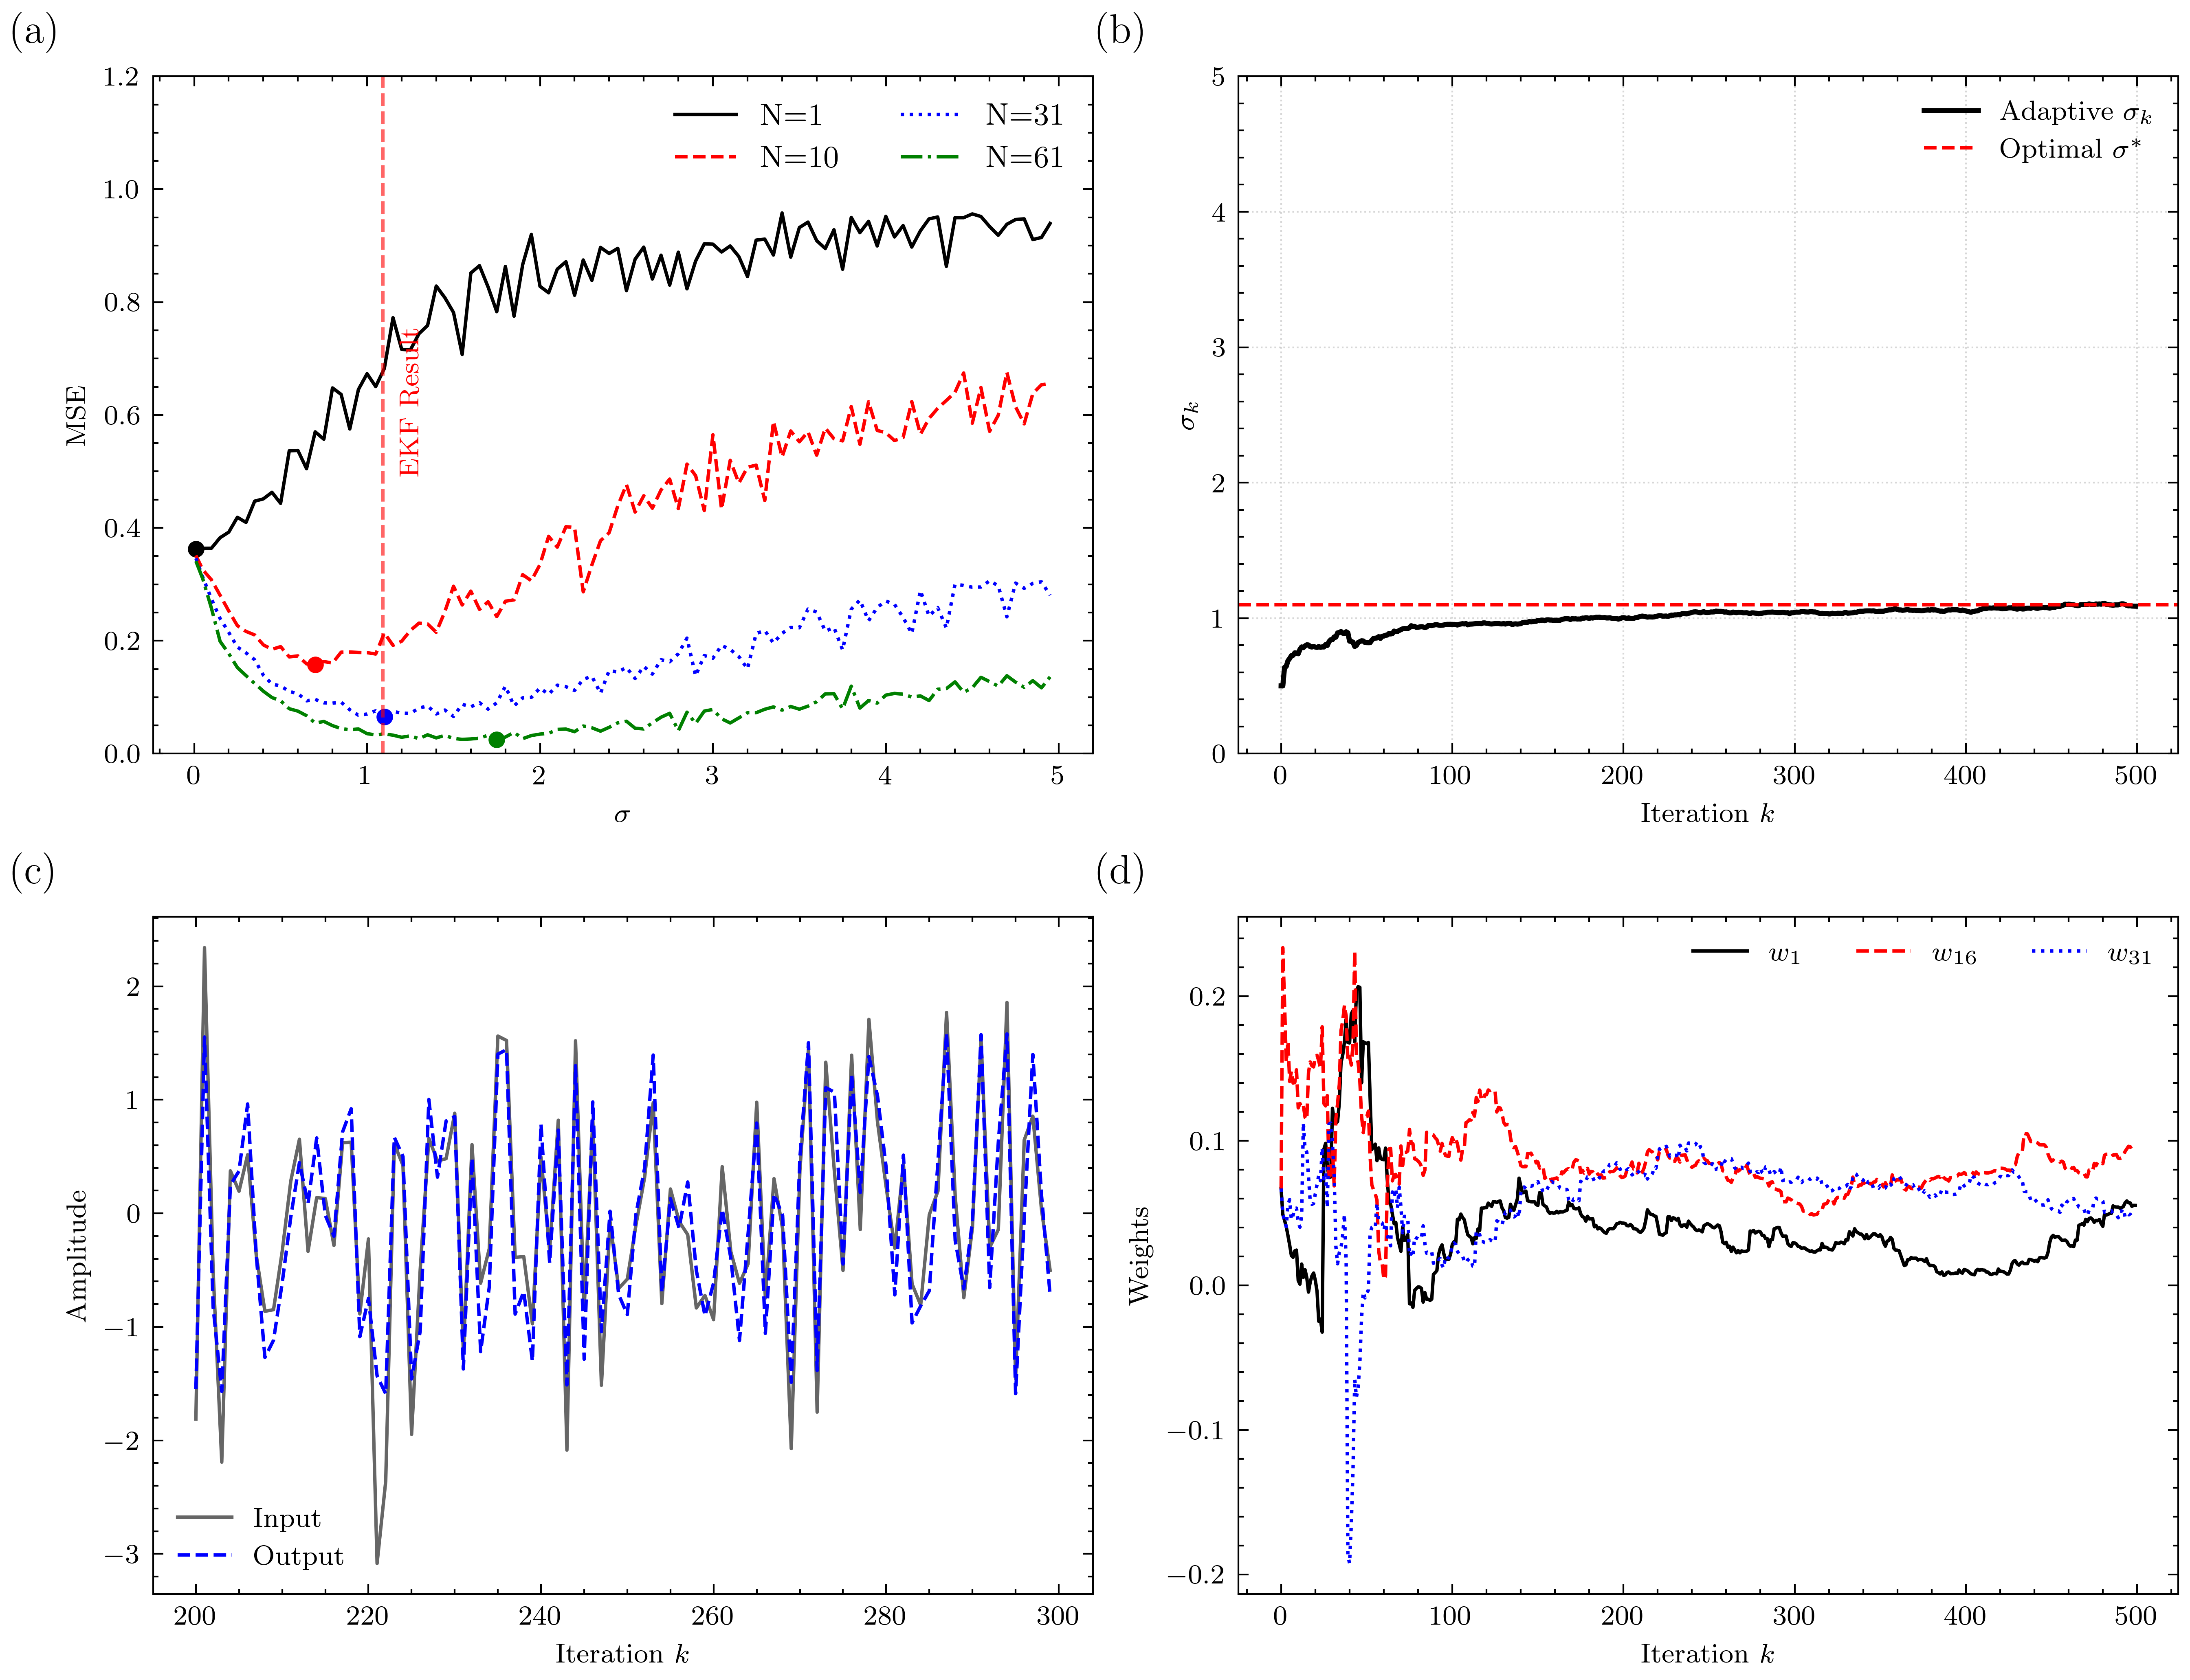

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots 

# --- 绘图风格设置 ---
plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 600
mpl.rcParams['axes.unicode_minus'] = False

# --- 基础函数定义 ---
def gaussian_pdf(x):
    """标准高斯分布概率密度函数"""
    return (1.0 / np.sqrt(2 * np.pi)) * torch.exp(-0.5 * x**2)

# 设置随机种子
seed_val = 451
torch.manual_seed(seed_val)
np.random.seed(seed_val)

# --- 全局参数 ---
# 【修改点1】增加数据长度以保证收敛。100点对于双自适应太短。
# 我们生成较长的数据用于跑算法，但绘图时可以截取。
Nx_total = 1000  
input_data = torch.randn(Nx_total, 1) # x_k

# ==========================================
# 第一部分：Grid Search (基准)
# ==========================================
# 注意：为了节省时间且Grid只是参考，我们只用前200个点跑Grid
Nx_grid = 200
print("正在运行 Grid Search 以获取基准曲线...")
S_grid = torch.cat([torch.tensor([0.01, 0.05]), torch.arange(0.1, 5.0, 0.05)])
N_values_grid = [1, 2, 10, 31, 61]
results_grid = {}

for N in N_values_grid:
    MSE_array = torch.zeros(len(S_grid))
    
    for i in range(len(S_grid)):
        # 初始化：这里为了公平，权重的“和”应该约为1
        w = torch.ones(N, 1) / N 
        P = torch.eye(N) * 10.0 # RLS初始P
        reg_param = 0.01
        
        Noise = S_grid[i] * torch.randn(Nx_grid, N)
        y_hat_hist = torch.zeros(Nx_grid)
        
        for k in range(Nx_grid):
            h_in = input_data[k, 0] + Noise[k, :]
            y = torch.sign(h_in).reshape(N, 1)
            
            # RLS
            denom = y.T @ P @ y + reg_param
            g = (P @ y) / denom
            err = input_data[k, 0] - y.T @ w
            w = w + g * err
            P = P - g @ y.T @ P
            
            y_hat_hist[k] = (y.T @ w).item()
            
        MSE_array[i] = torch.mean((input_data[:Nx_grid, 0] - y_hat_hist)**2)
        
    min_mse, min_idx = torch.min(MSE_array, dim=0)
    results_grid[N] = {
        'S': S_grid,
        'MSE': MSE_array,
        'best_mse': min_mse,
        'best_S': S_grid[min_idx]
    }

print("Grid Search 完成。")
print(results_grid[N])
# ==========================================
# 第二部分：Adaptive EKF + RLS (在线寻优)
# ==========================================
print("\n正在运行 Adaptive EKF (N=31)...")

N_adapt = 31
# 【修改点2】权重初始化归一化！
w_adpt = torch.ones(N_adapt, 1) / N_adapt 

P_rls = torch.eye(N_adapt) * 10.0
lambda_rls = 0.995 # 稍微加一点遗忘因子，适应sigma的变化

# EKF 参数
sigma_curr = 0.5  # 初始劣质值
P_sigma = 0.1     # 初始方差
Q_sigma = 1e-4    # 过程噪声 (过大会导致抖动，过小导致收敛慢)
R_sigma = 1.0     # 观测噪声方差
sigma_min = 0.03

sigma_history = torch.zeros(Nx_total)
y_hat_adpt = torch.zeros(Nx_total)
w_history = torch.zeros(Nx_total, N_adapt)

for k in range(Nx_total):
    x_k = input_data[k, 0]
    
    # 1. 物理过程 (产生观测)
    noise_vec = sigma_curr * torch.randn(N_adapt, 1) 
    y_vec = torch.sign(x_k + noise_vec) 
    
    # 2. RLS 更新权重 (Standard RLS)
    denom = y_vec.T @ P_rls @ y_vec + 0.1 # 正则化稍大一点保证数值稳定
    g_rls = (P_rls @ y_vec) / denom
    
    # 先计算预测输出 (用于EKF误差)
    y_hat_k = (w_adpt.T @ y_vec).item()
    e_k = x_k - y_hat_k 
    
    # RLS 更新
    w_adpt = w_adpt + g_rls * e_k
    P_rls = (P_rls - g_rls @ y_vec.T @ P_rls) / lambda_rls
    
    # 3. EKF 更新 Sigma
    # 预测
    sigma_pred = sigma_curr 
    P_sigma_pred = P_sigma + Q_sigma
    
    # Jacobian 计算
    # H = d(output)/d(sigma). 对于 SR，H 通常为负 (噪声大，增益小)
    sum_w = torch.sum(w_adpt) # 当前总权重
    # 防止分母为0
    s_safe = max(sigma_pred, 0.01) 
    u = x_k / s_safe
    pdf_val = gaussian_pdf(u)
    
    # H_k 公式: - (Sum W) * (2x / sigma^2) * f(x/sigma)
    # 注意：如果 x_k 接近 0，梯度信息很弱。
    H_k = - sum_w * (2 * x_k / (s_safe**2)) * pdf_val
    
    # 卡尔曼增益
    S_innov = H_k**2 * P_sigma_pred + R_sigma
    K_sigma = P_sigma_pred * H_k / S_innov
    
    # 更新状态
    # e_k = x_k - y_hat (residual)
    sigma_new = sigma_pred + K_sigma * e_k
    
    # 硬约束
    sigma_new = torch.clamp(sigma_new, min=sigma_min, max=8.0)
    
    # 更新协方差
    P_sigma = (1 - K_sigma * H_k) * P_sigma_pred
    
    # 记录
    sigma_history[k] = sigma_curr
    sigma_curr = sigma_new.item()
    y_hat_adpt[k] = y_hat_k
    w_history[k] = w_adpt.flatten()

# 计算最后阶段的稳态MSE
steady_state_idx = 500
final_mse_adpt = torch.mean((input_data[steady_state_idx:, 0] - y_hat_adpt[steady_state_idx:])**2)
final_sigma_val = torch.mean(sigma_history[steady_state_idx:])

print(f"Adaptive EKF 完成。稳态平均 MSE: {final_mse_adpt:.4f}")
print(f"Sigma 收敛至: {final_sigma_val:.4f} (Grid最优值: {results_grid[31]['best_S']:.4f})")


# ==========================================
# 第三部分：绘图 (截取部分数据展示)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
axes = axes.flatten()
labels_txt = ['(a)', '(b)', '(c)', '(d)']

# --- (a) MSE Landscape ---
ax = axes[0]
for idx, N_val in enumerate([1, 10, 31, 61]):
    res = results_grid[N_val]
    # 归一化为了好看？不，直接画原始MSE
    ax.plot(res['S'], res['MSE'], label=f'N={N_val}')
    ax.scatter(res['best_S'], res['best_mse'], s=15)

# 标记 EKF 结果
ax.axvline(final_sigma_val, color='r', linestyle='--', alpha=0.6)
ax.text(final_sigma_val+0.1, 0.5, r'EKF Result', color='r', rotation=90)

ax.set_xlabel(r'$\sigma$')
ax.set_ylabel('MSE')
ax.set_ylim([0, 1.2])
ax.legend(fontsize=9, ncol=2)
ax.text(-0.15, 1.05, labels_txt[0], transform=ax.transAxes, fontsize=12, weight='bold')

# --- (b) Sigma Evolution (前500点) ---
ax = axes[1]
plot_len = 500
k_axis = np.arange(plot_len)
ax.plot(k_axis, sigma_history[:plot_len].numpy(), 'k-', linewidth=1.5, label=r'Adaptive $\sigma_k$')
ax.axhline(results_grid[31]['best_S'], color='r', linestyle='--', label=r'Optimal $\sigma^*$')

ax.set_xlabel('Iteration $k$')
ax.set_ylabel(r'$\sigma_k$')
ax.legend()
ax.set_ylim([0, 5.0])
ax.text(-0.15, 1.05, labels_txt[1], transform=ax.transAxes, fontsize=12, weight='bold')
ax.grid(True, linestyle=':', alpha=0.5)

# --- (c) Tracking (取一段中间的) ---
ax = axes[2]
start_k = 200
end_k = 300
ax.plot(np.arange(start_k, end_k), input_data[start_k:end_k].numpy(), 'k-', alpha=0.6, label='Input')
ax.plot(np.arange(start_k, end_k), y_hat_adpt[start_k:end_k].numpy(), 'b--', label='Output')
ax.set_xlabel('Iteration $k$')
ax.set_ylabel('Amplitude')
ax.legend()
ax.text(-0.15, 1.05, labels_txt[2], transform=ax.transAxes, fontsize=12, weight='bold')

# --- (d) Weights ---
ax = axes[3]
# 归一化权重展示
for i in [0, 15, 30]:
    ax.plot(k_axis, w_history[:plot_len, i].numpy(), label=f'$w_{{{i+1}}}$')
ax.set_xlabel('Iteration $k$')
ax.set_ylabel('Weights')
ax.legend(ncol=3, fontsize=8)
ax.text(-0.15, 1.05, labels_txt[3], transform=ax.transAxes, fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

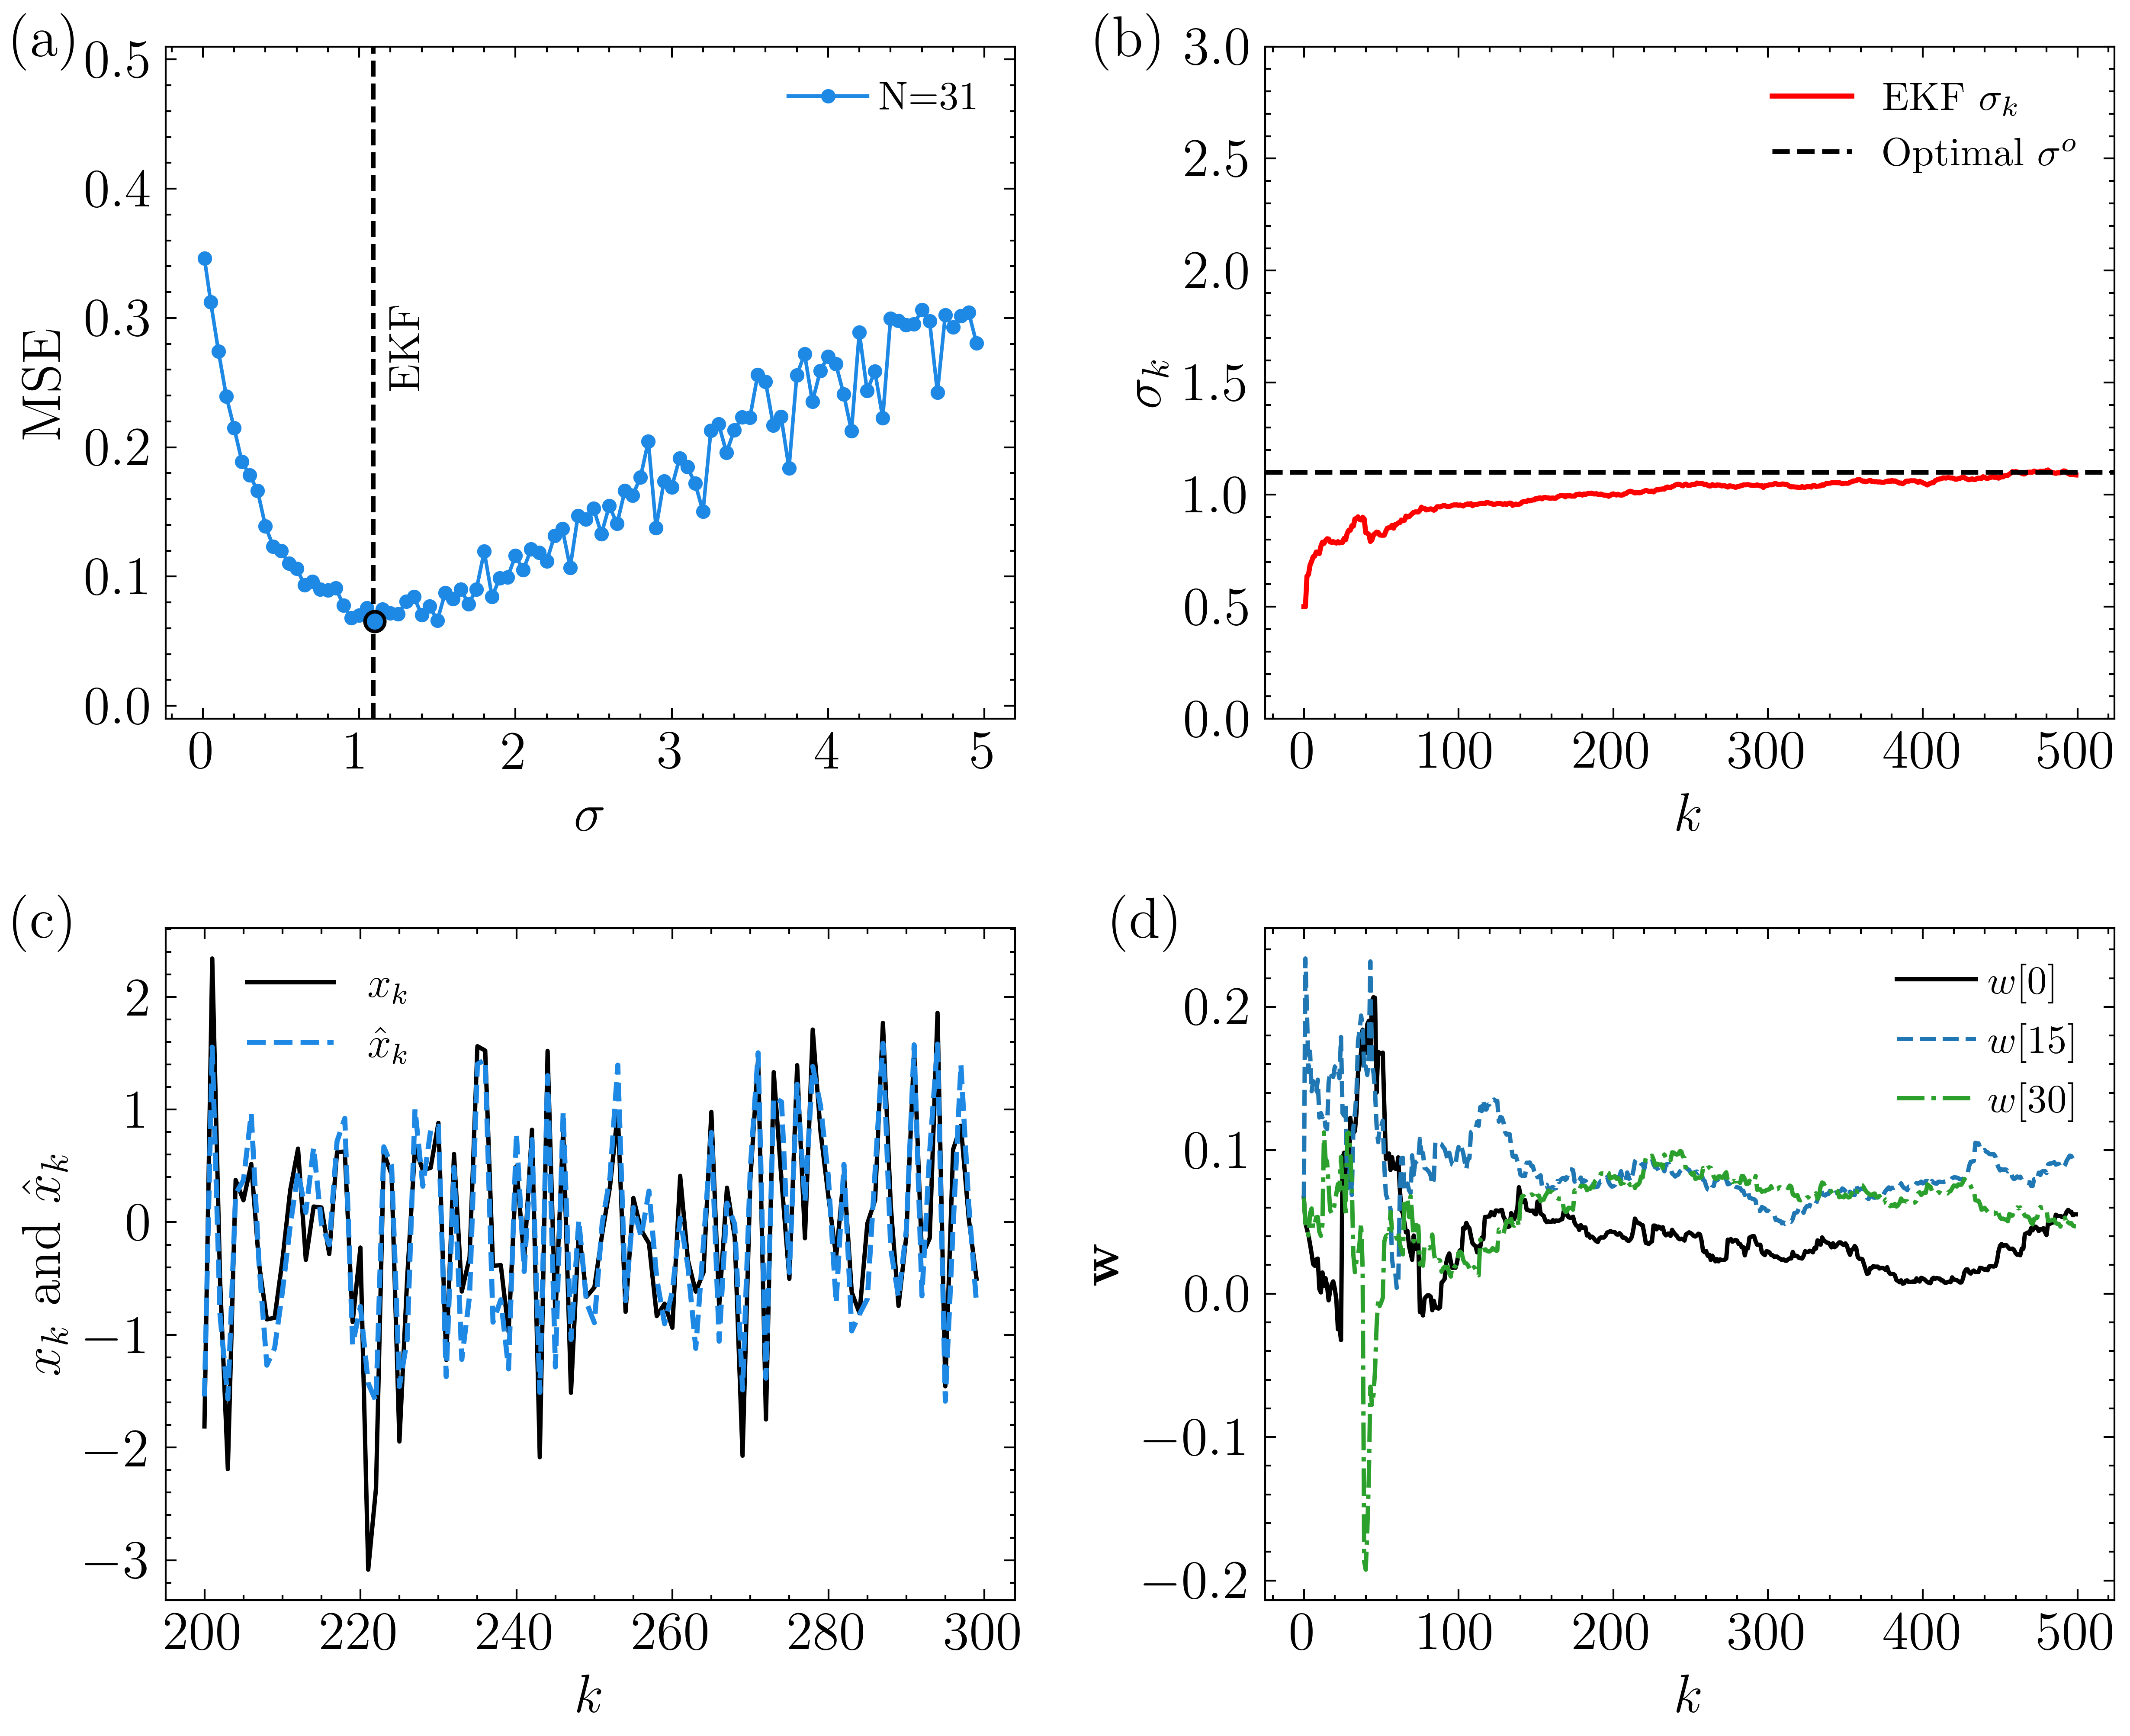

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 全局绘图风格（完全对齐 Fig.3）
# =========================================================
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
    'figure.titlesize': 15
})

colors = [
    '#1E88E5',  # 蓝
    '#43A047',  # 绿
    '#E53935',  # 红
    '#8E24AA',  # 紫
    '#FB8C00'   # 橙
]

linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]
markers = ['o', '>', '*', 's', '.']

# =========================================================
# 2 × 2 子图
# =========================================================
fig, axes = plt.subplots(2, 2, figsize=(8.5, 7))
axes = axes.flatten()
subplot_labels = ['(a)', '(b)', '(c)', '(d)']

# =========================================================
# (a) MSE Landscape
# =========================================================
ax = axes[0]
for i, N_val in enumerate([31]):
    res = results_grid[N_val]

    ax.plot(
        res['S'],
        res['MSE'],
        linestyle=linestyles[i],
        color=colors[i],
        marker=markers[i],
        markersize=3,
        label=f'N={N_val}'
    )

    ax.scatter(
        res['best_S'],
        res['best_mse'],
        color=colors[i],
        s=30,
        zorder=5,
        edgecolors='black'
    )

# EKF 结果
ax.axvline(final_sigma_val, color='black', linestyle='--', linewidth=1.2)
ax.text(final_sigma_val + 0.1, 0.25, 'EKF', rotation=90, fontsize=12)

ax.set_xlabel(r'$\sigma$')
ax.set_ylabel('MSE')
ax.set_ylim([-0.01, 0.51])
ax.set_yticks(np.arange(0, 0.51, 0.1))
ax.set_xticks(np.arange(0, 6, 1))

ax.legend(
    loc='upper right',
    ncol=2,
    fontsize=11,
    columnspacing=0.6,
    handletextpad=0.3
)

ax.grid(False)
ax.text(-0.18, 1.05, subplot_labels[0],
        transform=ax.transAxes,
        fontsize=16, fontweight='bold', va='top')

# =========================================================
# (b) Adaptive σ 演化
# =========================================================
ax = axes[1]

plot_len = 500
k_axis = np.arange(plot_len)

ax.plot(
    k_axis,
    sigma_history[:plot_len].numpy(),
    linestyle='-',
    color='red',
    linewidth=1.4,
    label=r'EKF $\sigma_k$'
)

ax.axhline(
    results_grid[31]['best_S'],
    color='black',
    linestyle='--',
    linewidth=1.3,
    label=r'Optimal $\sigma^o$'
)

ax.set_xlabel(r'$k$')
ax.set_ylabel(r'$\sigma_k$')
ax.set_ylim([0, 3.0])
ax.set_xticks(np.arange(0, 501, 100))

ax.legend(loc='upper right', fontsize=11)
ax.grid(False)

ax.text(-0.2, 1.05, subplot_labels[1],
        transform=ax.transAxes,
        fontsize=16, fontweight='bold', va='top')

# =========================================================
# (c) Tracking Performance
# =========================================================
ax = axes[2]

start_k, end_k = 200, 300
k_seg = np.arange(start_k, end_k)

ax.plot(
    k_seg,
    input_data[start_k:end_k].numpy(),
    linestyle='-',
    color='black',
    linewidth=1.2,
    label=r'$x_k$'
)

ax.plot(
    k_seg,
    y_hat_adpt[start_k:end_k].numpy(),
    linestyle='--',
    color=colors[0],
    linewidth=1.4,
    label=r'$\hat{x}_k$'
)

ax.set_xlabel(r'$k$')
ax.set_ylabel(r'$x_k$ and $\hat{x}_k$')
ax.set_xticks(np.arange(start_k, end_k + 1, 20))

ax.legend(
    loc='upper left',
    bbox_to_anchor=(0.05, 1.0),  # 向右挪一点（0.2~0.3 都很常用）
    fontsize=12
)
ax.grid(False)

ax.text(-0.18, 1.05, subplot_labels[2],
        transform=ax.transAxes,
        fontsize=16, fontweight='bold', va='top')

# =========================================================
# (d) Weight Evolution
# =========================================================
ax = axes[3]

weight_ids = [0, 15, 30]
line_styles = ['-', '--', '-.']
colors_w = ['k', '#1f77b4', '#2ca02c']

for i, idx in enumerate(weight_ids):
    ax.plot(
        k_axis,
        w_history[:plot_len, idx].numpy(),
        linestyle=line_styles[i],
        linewidth=1.2,
        color=colors_w[i],
        label=fr'$w[{idx}]$'
    )

ax.set_xlabel(r'$k$')
ax.set_ylabel(r'$\mathbf{w}$')
ax.set_xticks(np.arange(0, 501, 100))

ax.legend(
    loc='upper right',
    fontsize=11,
    ncol=1,
    columnspacing=0.6,
    handletextpad=0.3
)

ax.grid(False)

ax.text(-0.18, 1.05, subplot_labels[3],
        transform=ax.transAxes,
        fontsize=16, fontweight='bold', va='top')

# =========================================================
# 保存与显示（IEEE EPS）
# =========================================================
fig.tight_layout()
fig.savefig(
    'D:/IEEE 2025 Adaptive weighted SSR/Fig_EKF_Comparison.eps',
    format='eps',
    dpi=800,
    bbox_inches='tight'
)
plt.show()
